# Stage 6m — Figure 7, four best-case seed-selection variants

**Purpose, and an explicit caveat up front:** this notebook is a sensitivity/
robustness exploration, not a proposed replacement for Figure 7. The real
Figure 7 (`5a_paper_plots.ipynb`) reports the *full, unselected* 50-seed (now
1000-seed, see Stage 6l/this session's cluster rerun) median +/- IQR for the
MESM vector emulator's baseline-vs-optimized comparison. That full picture
(`data/SI_results/seed_uncertainty/fig7_seed_spread_co2_only_MESM_1000seed.pkl`)
already showed: baseline beats every optimized variant on the overall
weighted metric in effectively every seed (0/1000, 1/1000, 9/1000 for
constant/sine/both respectively), with two real, narrower exceptions -
`both` reliably helps Tier 2 (~98.5% of seeds) and `sine` reliably helps DECK
(~99.2% of seeds).

This notebook asks a different, deliberately biased question: **what would
Figure 7 look like if we selected only the 50 best-performing seeds**, under
four different selection criteria? This is a controlled illustration of
cherry-picking risk / best-case upper bound - useful for understanding how
much a small, favorably-selected seed sample can visually overstate the
optimized emulator's advantage relative to the full, honest 1000-seed
picture above. **Not intended for the manuscript as-is.**

All four panels plot median with IQR (`utils_plotting.plot_scenario_
difference_bars2`'s new `seed_agg="median_iqr"` option, added this session -
the function previously only supported mean +/- std for its seed-spread
error bars).

**Selection criteria** (all four use each seed's overall weighted NRMSE -
Tier 1:7 / Tier 2:5 / DECK:2 / CS3:2, the same weighting convention used
throughout this session and matching `4c_MESM_baseline_hp_search.py`'s own
scoring):

1. Top 50 seeds ranked by `optimal_constant`'s own weighted NRMSE (lowest/
   best 50). The *same* 50 seed indices are then used to pull `baseline`,
   `optimal_sine`, and `optimal_both` for those seeds too - not independently
   top-50 for those series.
2. Same, ranked by `optimal_sine`.
3. Same, ranked by `optimal_both`.
4. Top 50 seeds ranked by the **mean of all three** optimized variants'
   weighted NRMSE per seed - i.e. seeds that are consistently good across
   `constant`, `sine`, *and* `both` simultaneously, not just on one axis.


In [1]:
import os, sys, pickle
sys.path.insert(0, ".")

import numpy as np
import utils_inverse
import utils_plotting

with open("data/SI_results/seed_uncertainty/fig7_seed_spread_co2_only_MESM_1000seed.pkl", "rb") as f:
    seed_cache = pickle.load(f)

N_SEEDS = len(seed_cache)
print(f"loaded seed cache: {N_SEEDS} seeds")

fig7_data = utils_inverse.load_fig7_emic_data()
print("fig7_data keys:", list(fig7_data.keys()))

loaded seed cache: 1000 seeds


fig7_data keys: ['baseline_results', 'optimized_results_list', 'scenario_keys', 'legend_labels', 'co2_data', 'global_mean_temp', 'x_labels', 'separator_indices', 'group_labels']


## 1. Per-seed weighted-NRMSE ranking

Same weighting convention as the rest of this session's Fig 7 analysis
(Tier 1:7 / Tier 2:5 / DECK:2 / CS3:2), computed directly from the seed-spread
cache's `[eval_set]['mean']['global']` entries - independent of the 16-
scenario bar-chart structure `plot_scenario_difference_bars2` itself uses.

In [2]:
WEIGHTS = {"Tier 1": 7, "Tier 2": 5, "DECK": 2, "CS3": 2}
W_SUM = sum(WEIGHTS.values())


def overall_score(seed, variant):
    entry = seed_cache[seed][variant]
    return sum(WEIGHTS[s] * entry[s]["mean"]["global"] for s in WEIGHTS) / W_SUM


scores = {
    variant: np.array([overall_score(s, variant) for s in range(N_SEEDS)])
    for variant in ["baseline", "optimal_constant", "optimal_sine", "optimal_both"]
}
combined_score = np.mean(
    [scores["optimal_constant"], scores["optimal_sine"], scores["optimal_both"]], axis=0
)

def top50(arr):
    return list(np.argsort(arr)[:50])

selections = {
    "top50_constant": top50(scores["optimal_constant"]),
    "top50_sine": top50(scores["optimal_sine"]),
    "top50_both": top50(scores["optimal_both"]),
    "top50_overall": top50(combined_score),
}

for name, idx in selections.items():
    crit = scores["optimal_" + name.split("_")[1]] if "overall" not in name else combined_score
    print(f"{name:16s} n={len(idx):3d}  criterion range [{crit[idx].min():.4f}, {crit[idx].max():.4f}]  "
          f"(full-1000 median={np.median(crit):.4f})")

top50_constant   n= 50  criterion range [0.0906, 0.0989]  (full-1000 median=0.1087)
top50_sine       n= 50  criterion range [0.0758, 0.0880]  (full-1000 median=0.1001)
top50_both       n= 50  criterion range [0.0785, 0.0848]  (full-1000 median=0.0925)
top50_overall    n= 50  criterion range [0.0897, 0.0947]  (full-1000 median=0.1010)


## 2. Build per-panel seed-restricted result lists, plot

For each panel, `seed_baseline_results`/`seed_optimized_results_list` are
restricted to that panel's 50 selected seed indices - the exact same
per-seed dict shapes `5a_paper_plots.ipynb`'s Fig 7 cell already uses
(`seed_cache[s]['baseline']` etc. match `get_global_value`'s expected
`{eval_set: {scenario: {'global': ...}}}` nesting directly, no reshaping
needed).

In [3]:
def build_seed_lists(seed_idx):
    seed_baseline = [seed_cache[s]["baseline"] for s in seed_idx]
    seed_opt_list = [
        [seed_cache[s]["optimal_constant"] for s in seed_idx],
        [seed_cache[s]["optimal_sine"] for s in seed_idx],
        [seed_cache[s]["optimal_both"] for s in seed_idx],
    ]
    return seed_baseline, seed_opt_list

### Panel 1 — top 50 seeds by `constant`

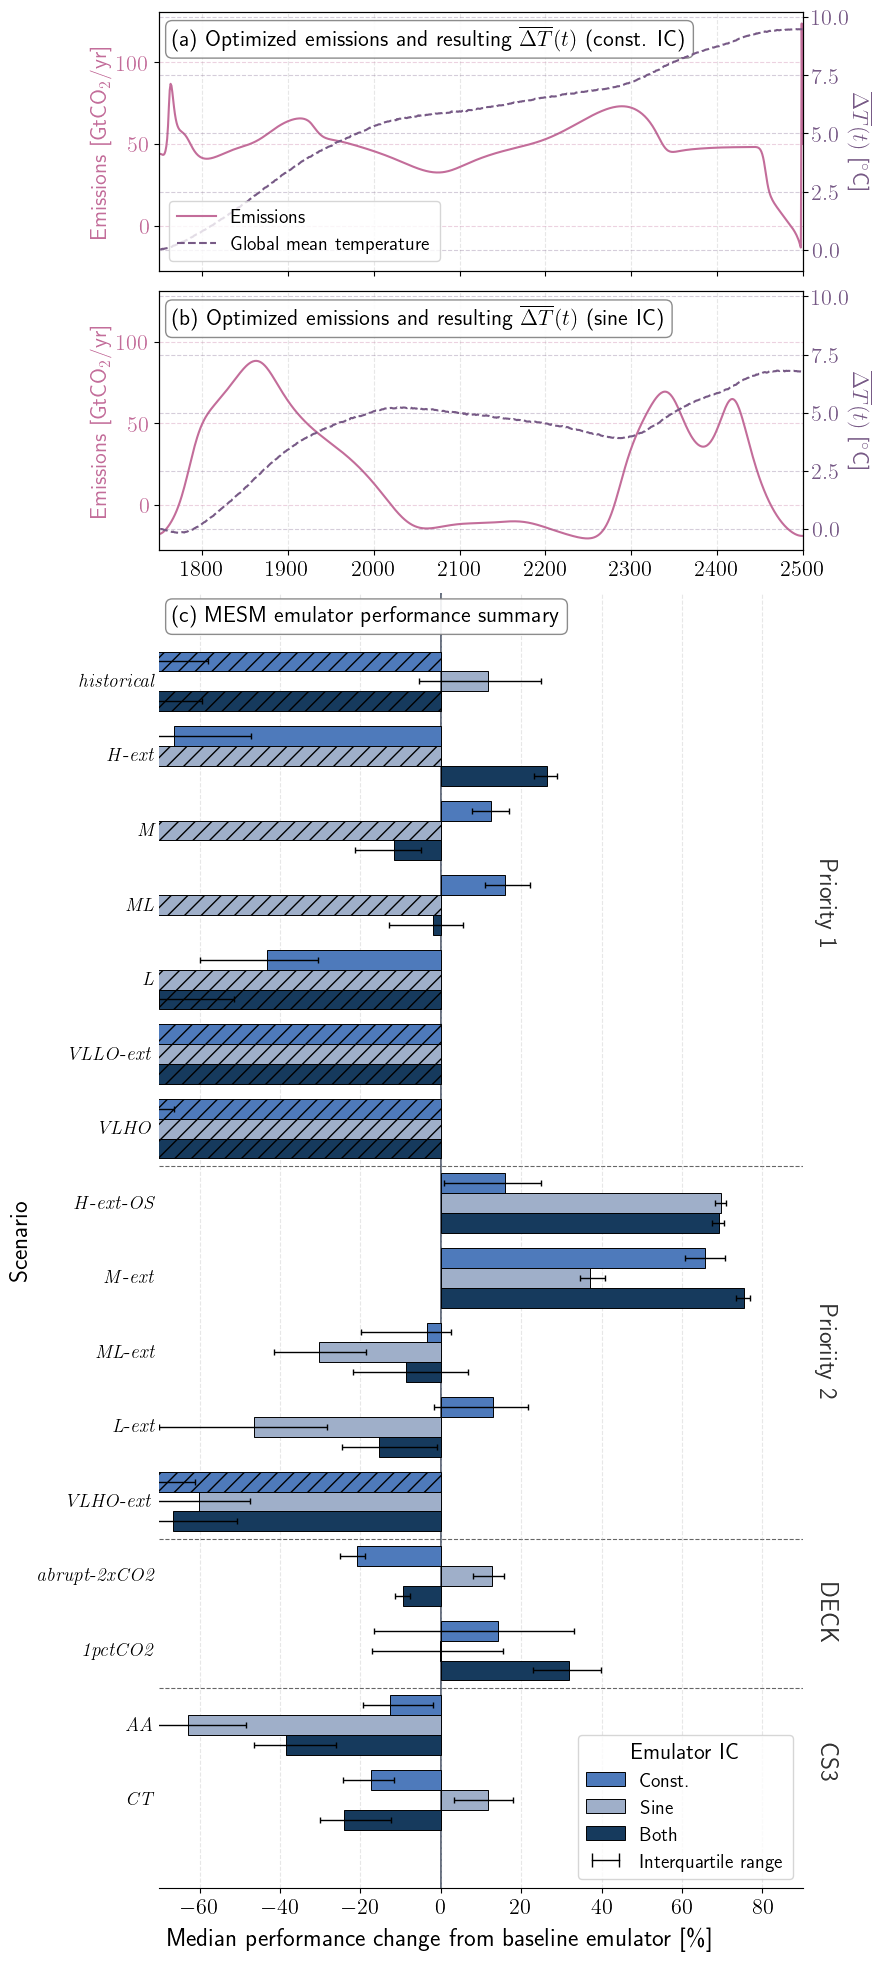

In [4]:
seed_baseline, seed_opt_list = build_seed_lists(selections["top50_constant"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data, save=True, figname="fig07_emic_summary_top50_constant",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)

### Panel 2 — top 50 seeds by `sine`

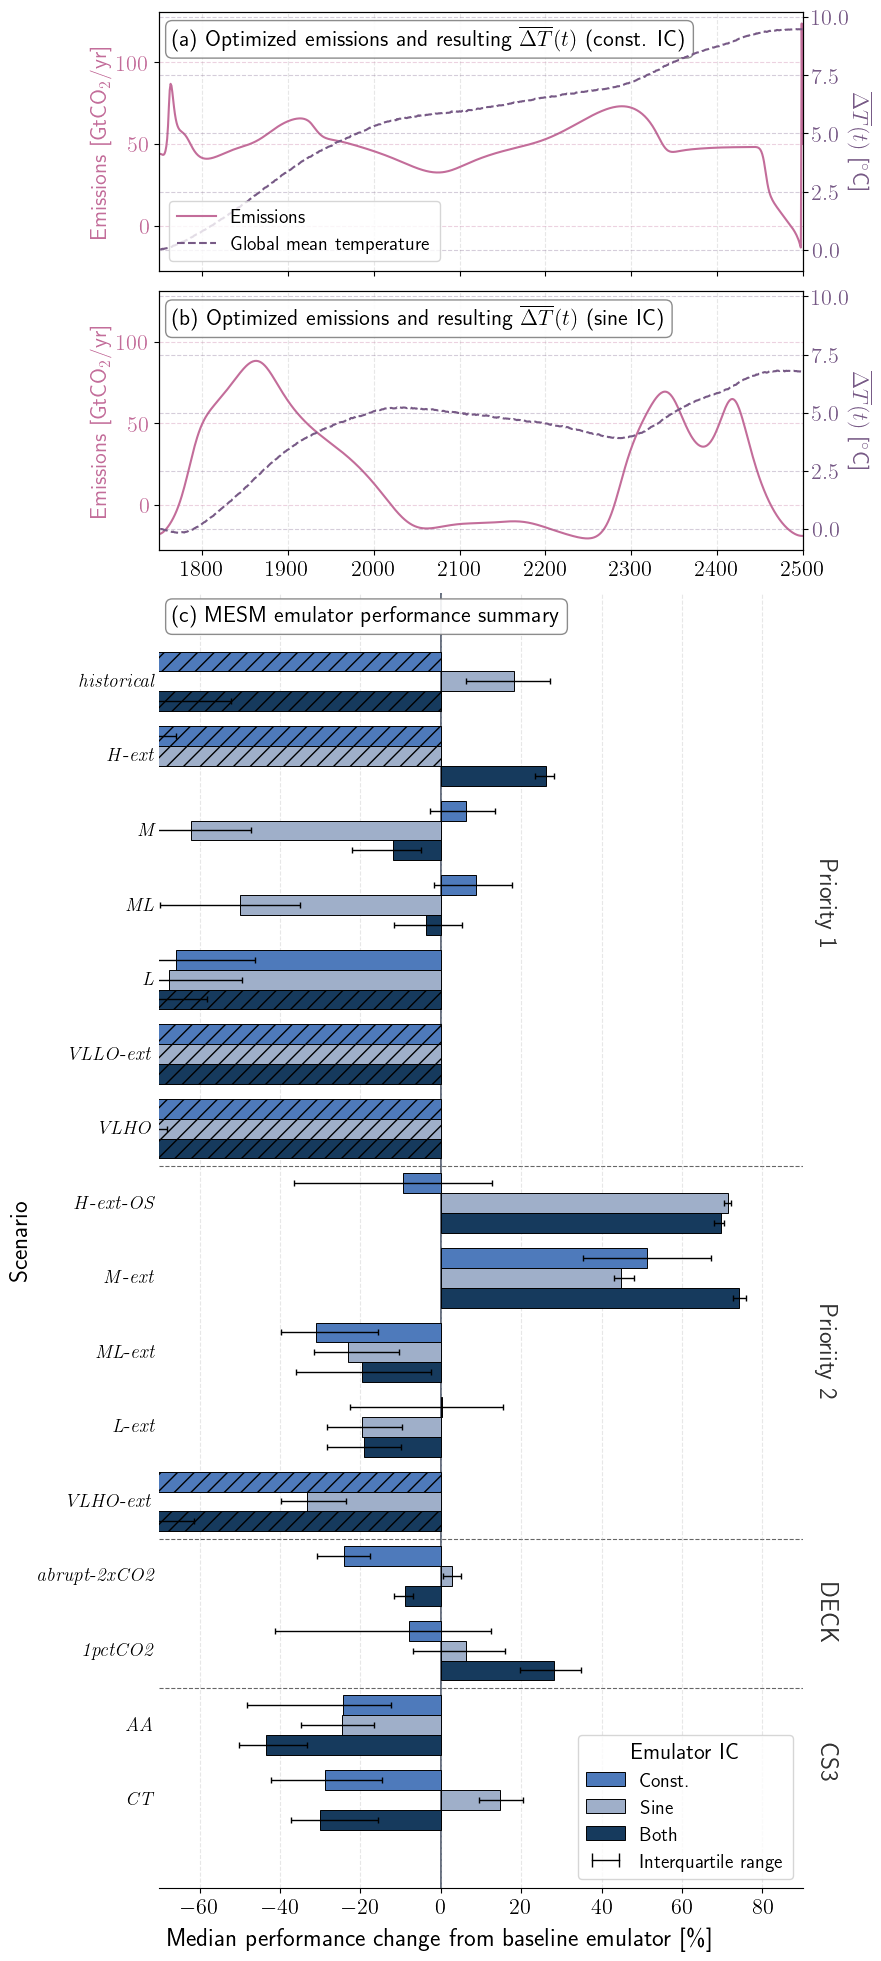

In [5]:
seed_baseline, seed_opt_list = build_seed_lists(selections["top50_sine"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data, save=True, figname="fig07_emic_summary_top50_sine",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)

### Panel 3 — top 50 seeds by `both`

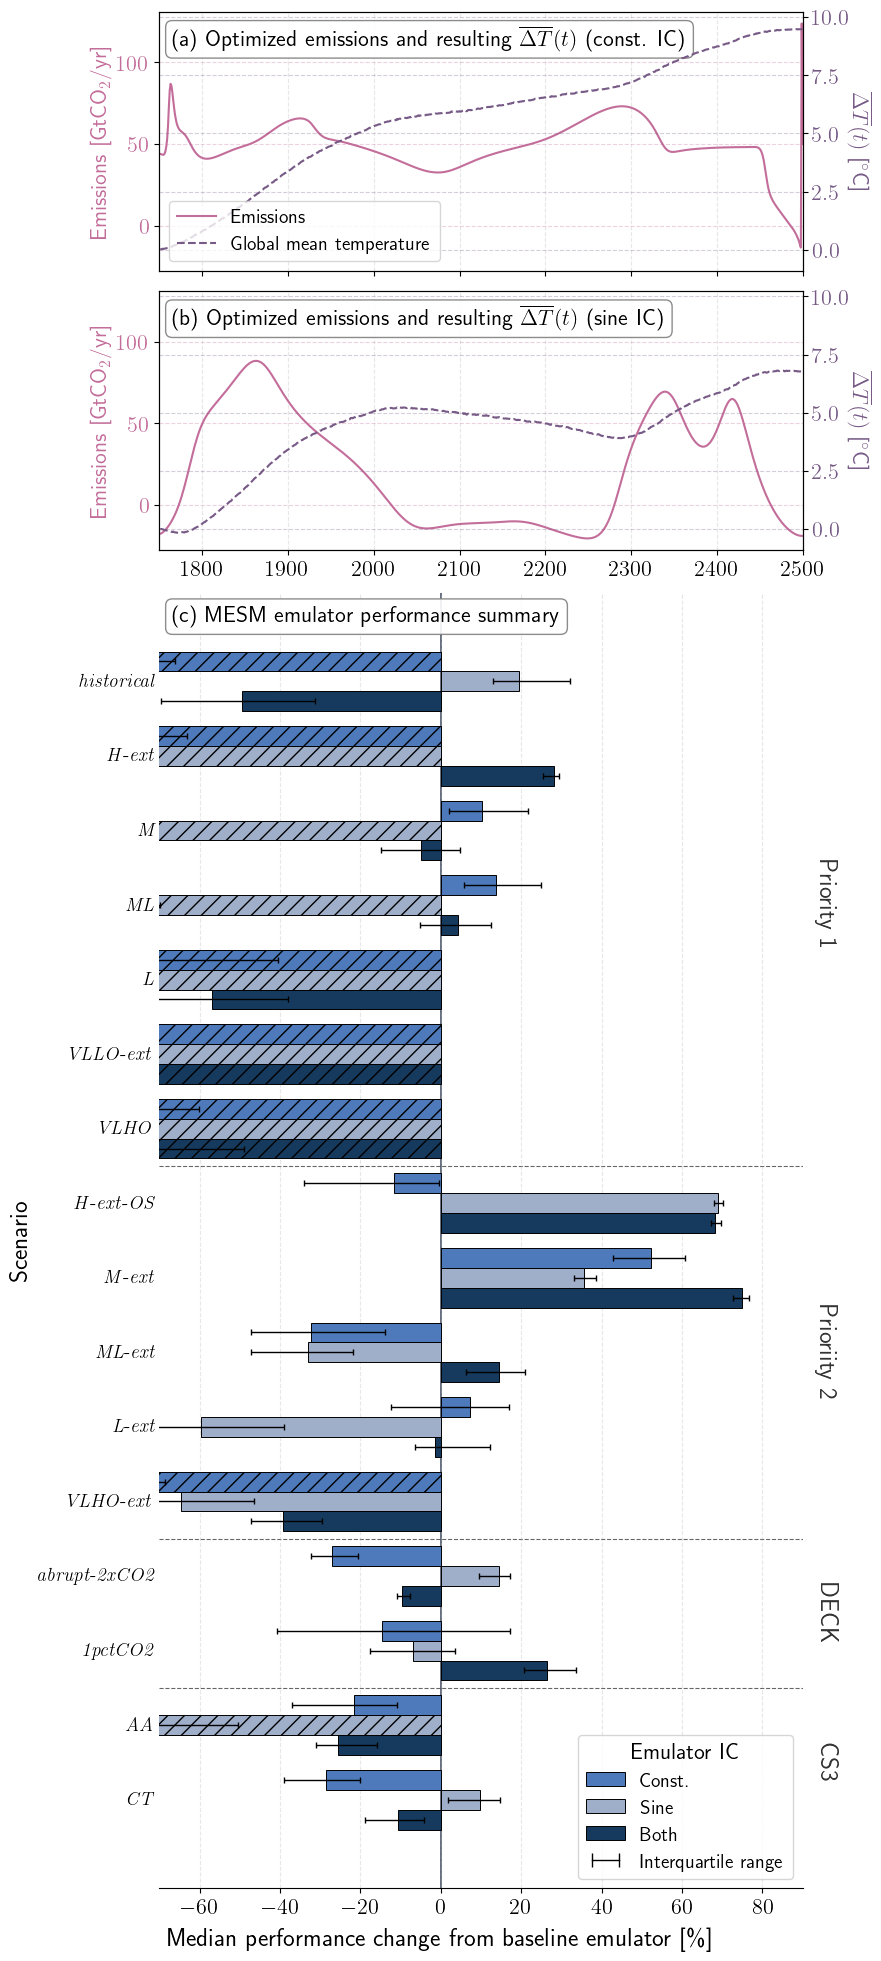

In [6]:
seed_baseline, seed_opt_list = build_seed_lists(selections["top50_both"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data, save=True, figname="fig07_emic_summary_top50_both",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)

### Panel 4 — top 50 seeds overall (consistently best across all 3 optimized variants)

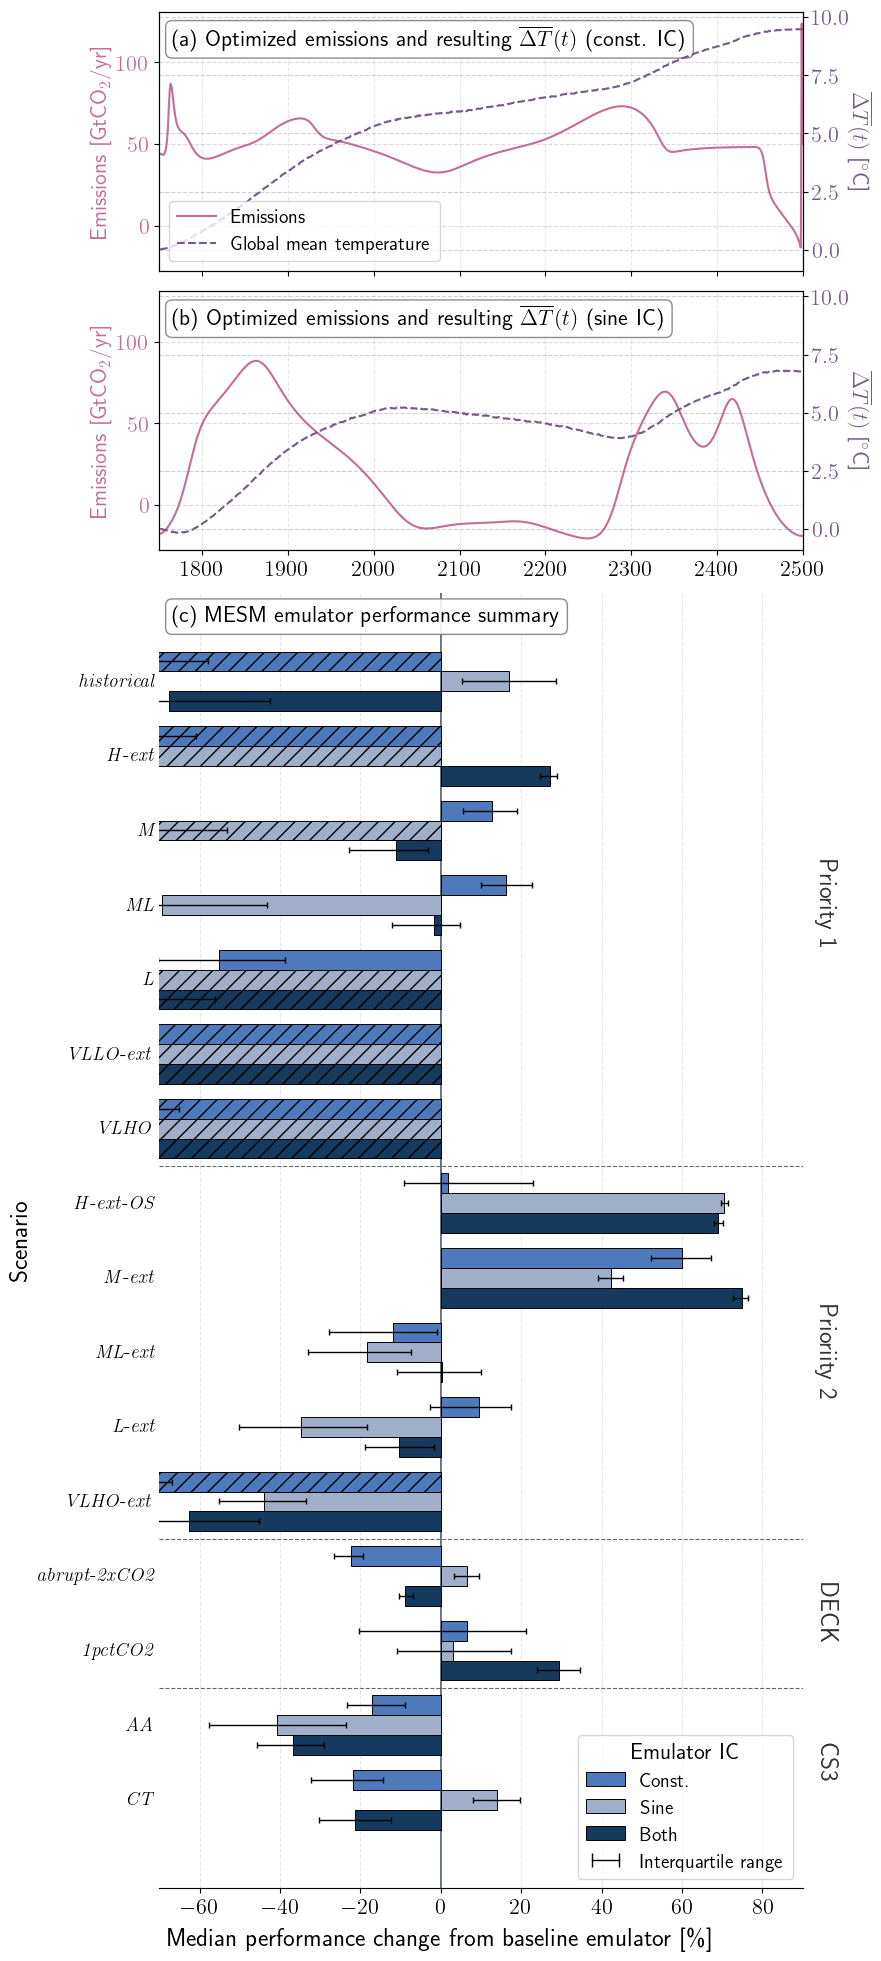

In [7]:
seed_baseline, seed_opt_list = build_seed_lists(selections["top50_overall"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data, save=True, figname="fig07_emic_summary_top50_overall",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)

## 3. Summary: how much does selection alone move the overall weighted NRMSE?

Same Tier1:7/Tier2:5/DECK:2/CS3:2 weighted metric as Section 1 and as the
full-1000-seed analysis earlier this session, now restricted to each panel's
50 selected seeds - quantifies how much of Figure 7's apparent
baseline-vs-optimized gap a favorable seed selection alone can manufacture,
relative to the honest full-1000 picture.

In [8]:
print(f"{'panel':16s} {'baseline':>10s} {'constant':>10s} {'sine':>10s} {'both':>10s}")
full_row = [np.median(scores[v]) for v in ['baseline', 'optimal_constant', 'optimal_sine', 'optimal_both']]
print(f"{'full (n=1000)':16s} " + " ".join(f"{v:10.4f}" for v in full_row))
print("-" * 60)

for name, idx in selections.items():
    idx = np.array(idx)
    row = [np.median(scores[v][idx]) for v in ['baseline', 'optimal_constant', 'optimal_sine', 'optimal_both']]
    print(f"{name:16s} " + " ".join(f"{v:10.4f}" for v in row))

panel              baseline   constant       sine       both
full (n=1000)        0.0785     0.1087     0.1001     0.0925
------------------------------------------------------------
top50_constant       0.0778     0.0972     0.0982     0.0914
top50_sine           0.0771     0.1097     0.0860     0.0931
top50_both           0.0778     0.1077     0.1009     0.0837
top50_overall        0.0775     0.1007     0.0906     0.0891


## 4. Panel 4 revisited — legend/axis-label fixes, plus a Priority-1-dropped variant

Two more versions of the `top50_overall` panel (same seed selection as
Section 2/Panel 4 - top 50 seeds by mean `constant`+`sine`+`both` score),
with three fixes now baked into `utils_plotting.plot_scenario_difference_
bars2` itself (so every future `seed_agg="median_iqr"` caller gets them,
not just these two):

1. The legend's IC swatches are now built from solid-color proxy `Patch`
   handles rather than the auto-generated bar-container handles - the
   latter picked up the per-bar clipping hatch (applied to individual bars
   whose value falls outside the x-axis range) whenever it happened to land
   on the legend's representative bar, which is why "Const." rendered
   hatched in the legend before even though the hatch is a clipping
   indicator, not a per-series property.
2. The legend gains an explicit "IQR" entry (a horizontal black line with
   vertical end-caps, mirroring the real errorbar style) - shown only when
   `seed_agg="median_iqr"` and seed-spread data was actually supplied.
3. The x-axis label now reads "Median performance change from baseline
   emulator [%]" instead of "Performance change from baseline emulator
   [%]" - again gated on `seed_agg="median_iqr"` with real seed data, so
   the original mean+/-std and single-run call sites are unaffected.

### Panel 4v2 — top 50 seeds overall, legend/label fixes, all scenario groups

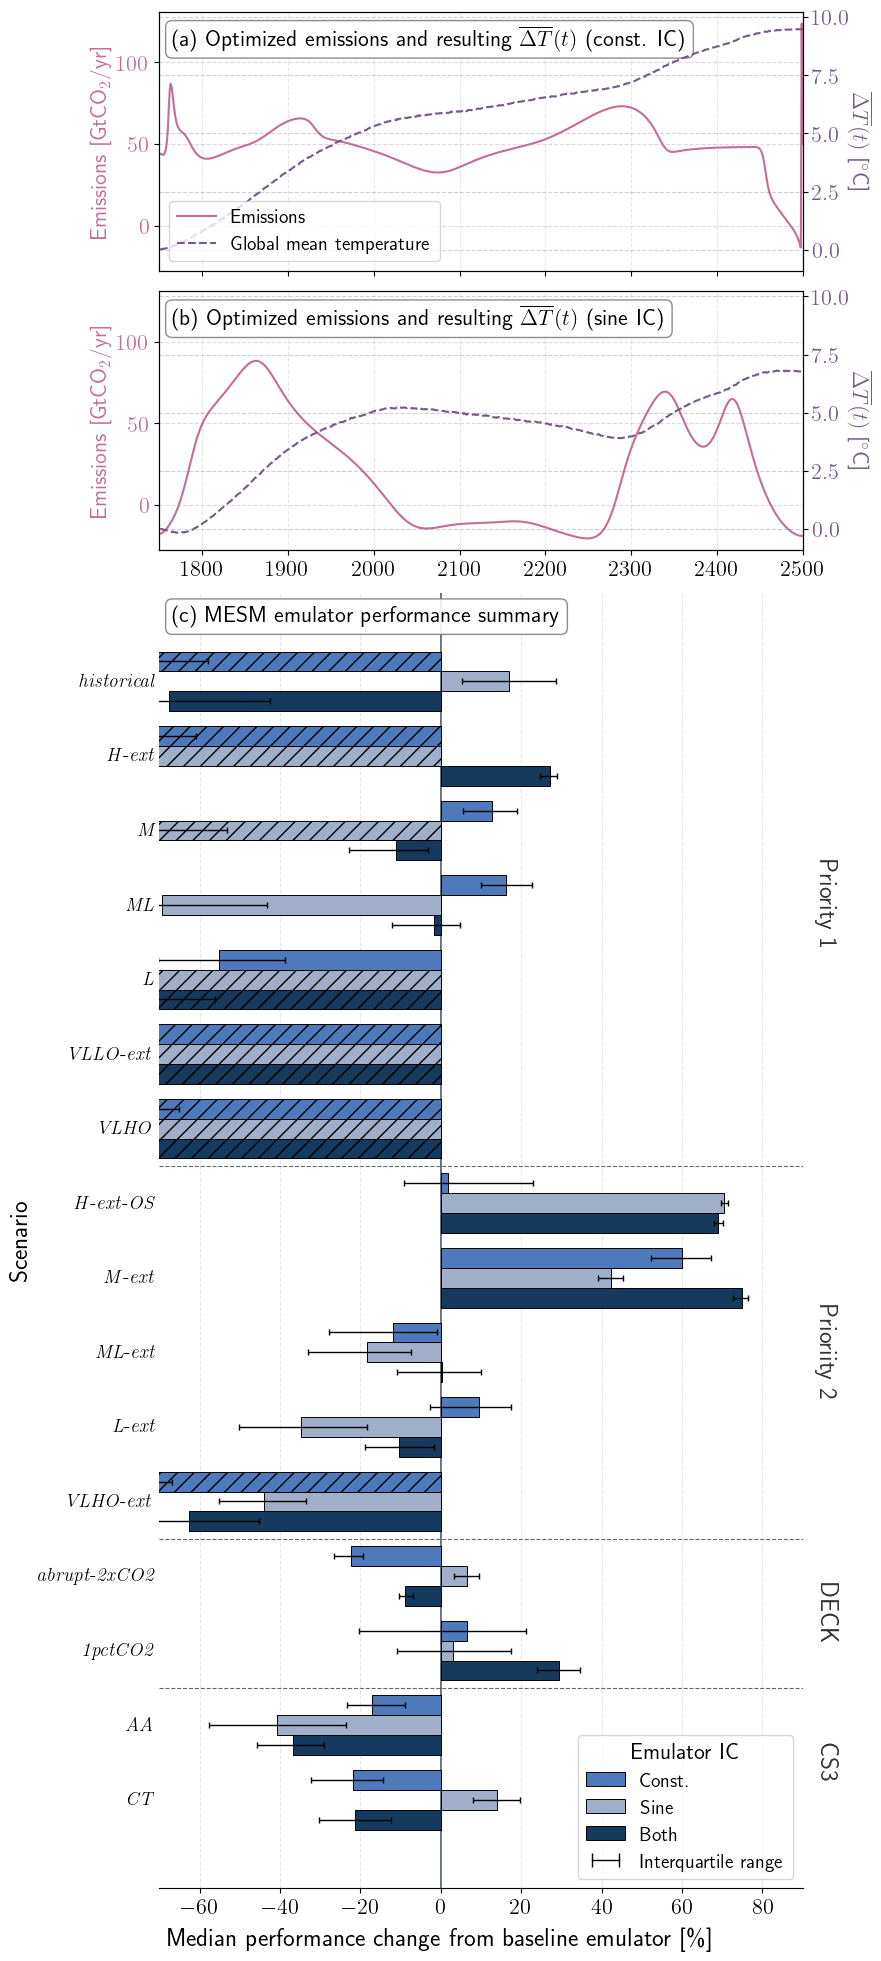

In [9]:
seed_baseline, seed_opt_list = build_seed_lists(selections["top50_overall"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data, save=True, figname="fig07_emic_summary_top50_overall_v2",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)

### Panel 4v2, Priority 1 dropped — Priority 2 / DECK / CS3 only

Same fixes and same seed selection, but `scenario_keys`/`x_labels`/
`separator_indices`/`group_labels` are restricted to the last 9 of the 16
scenarios (dropping the 7 Priority-1 scenarios: `historical`, `H-ext`, `M`,
`ML`, `L`, `VLLO-ext`, `VLHO`). `baseline_results`/`optimized_results_list`/
`seed_*_results` are left as full dicts - `get_global_value` only looks up
whatever scenario names appear in `scenario_keys`, so nothing needs
reshaping, just the keys/labels/group-boundary lists.

scenarios kept: ['H-ext-OS', 'M-ext', 'ML-ext', 'L-ext', 'VLHO-ext', '2xCO2', '1pctCO2', 'AA', 'CT']


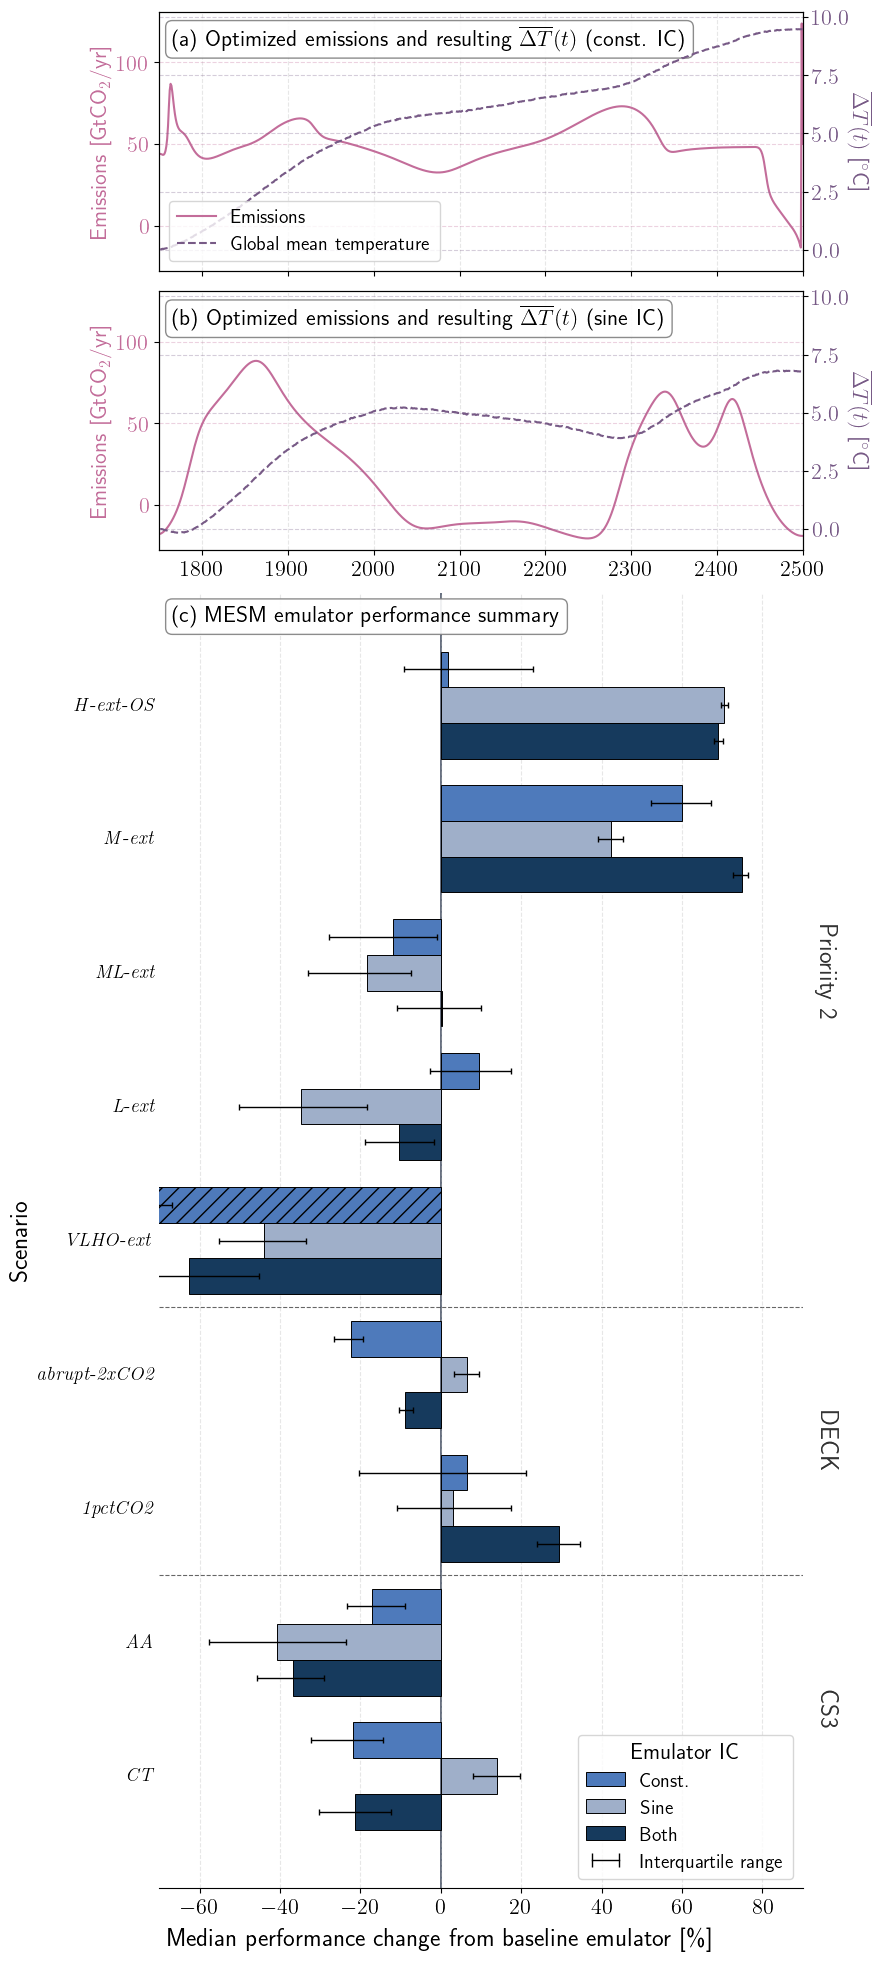

In [10]:
fig7_data_no_p1 = dict(fig7_data)
fig7_data_no_p1["scenario_keys"] = fig7_data["scenario_keys"][7:]
fig7_data_no_p1["x_labels"] = fig7_data["x_labels"][7:]
fig7_data_no_p1["separator_indices"] = [4, 6]
fig7_data_no_p1["group_labels"] = fig7_data["group_labels"][1:]
print("scenarios kept:", fig7_data_no_p1["scenario_keys"])

seed_baseline, seed_opt_list = build_seed_lists(selections["top50_overall"])
utils_plotting.plot_scenario_difference_bars2(
    **fig7_data_no_p1, save=True, figname="fig07_emic_summary_top50_overall_v2_no_priority1",
    seed_baseline_results=seed_baseline, seed_optimized_results_list=seed_opt_list,
    seed_agg="median_iqr",
)